In [8]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans

In [4]:
image_path = "../output_videos/cropped_image.jpg"
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

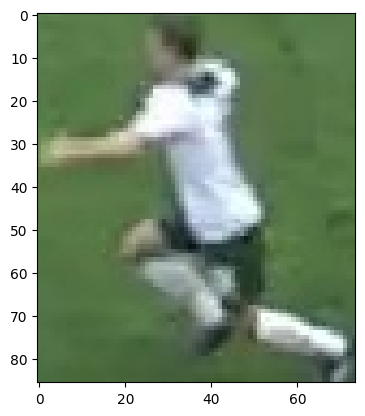

In [5]:
plt.imshow(image)
plt.show()

#pegar a metade superior da imagem

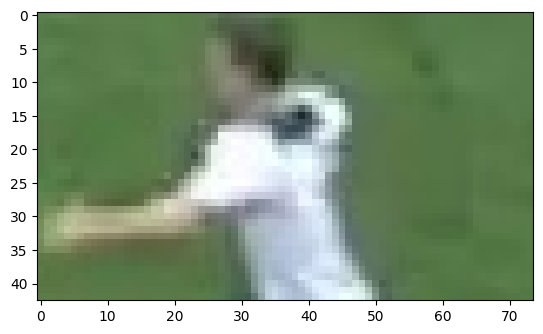

In [ ]:
top_half_image=  image[0: int(image.shape[0]/2), :]
plt.imshow(top_half_image)
plt.show()
#imagem pela metade

#reseumir a imagem em 2 cores , separar o capo da camisa

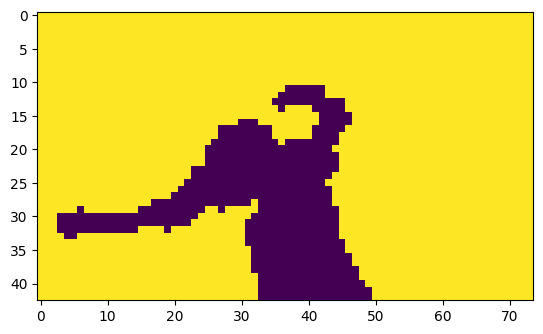

In [9]:
# mudar a igame para um formato 2D onde cada linha é um pixel e as colunas são os canais de cor (R,G,B)
image_2d = top_half_image.reshape(-1, 3)

# usar k-means para separa em 2
kmeans = KMeans(n_clusters=2, random_state=0)
kmeans.fit(image_2d)

# pegar os rótulos de cada pixel
labels = kmeans.labels_

# reformar os rótulos para a forma original da imagem
clustered_image = labels.reshape(top_half_image.shape[0], top_half_image.shape[1])

#resultados da nova imagem
plt.imshow(clustered_image)
plt.show()

In [10]:
# pegar as bordas da imagem amarela podemos contar qual cluster é mais frequente,podemos assumir que mais frequente é o fundo (não jogador)
corner_clusters = [clustered_image[0, 0], clustered_image[0, -1], clustered_image[-1, 0], clustered_image[-1, -1]]
non_player_cluster = max(set(corner_clusters), key=corner_clusters.count)
print(non_player_cluster)

1


In [11]:
player_cluster = 1-non_player_cluster
print(player_cluster)

0


In [ ]:
# 1 é o fundo e 0 é o jogador
kmeans.cluster_centers_[player_cluster]
#entrega um cor RGB do que o jogador esta vestindo 

array([198.69479354, 209.005386  , 211.68222621])